# Baseline Demographic Distribution — Exploratory Analysis

**Project:** MLLM Persona Simulation  
**Dataset:** `data/baseline_distribution.csv` — 1,008 synthetic persona seeds  
**Design:** Fully combinatorial — all 24 profiles covered equally (42 agents each)  
**Purpose:** Confirm profile completeness and balance across a 2 × 2 × 2 × 3 factorial design.
The key insight is that this is a controlled synthetic experiment, not a population sample:
every combination of (gender × economic status × political orientation × personality) is
equally represented.

---

## Outline
1. [Load & Validate](#1-load--validate)
2. [Profile Space Overview](#2-profile-space-overview)
3. [Univariate Distributions](#3-univariate-distributions)
4. [Pairwise Cross-Tabs & Heatmaps](#4-pairwise-cross-tabs--heatmaps)
5. [Diversity & Balance Metrics](#5-diversity--balance-metrics)
6. [Report-Ready Figures](#6-report-ready-figures)
7. [Summary Statistics Table](#7-summary-statistics-table)

---
## 0  Environment

In [1]:
import sys
from pathlib import Path

try:
    ROOT = Path(__file__).resolve().parent.parent
except NameError:
    _cwd = Path.cwd()
    ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd

sys.path.insert(0, str(ROOT / "src"))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import entropy

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
PALETTE = sns.color_palette("muted")

FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Root    : {ROOT}")
print(f"Figures → {FIGURES_DIR}")

Root    : /mnt/raid5/neemias/mllm-persona-simulation
Figures → /mnt/raid5/neemias/mllm-persona-simulation/figures


---
## 1  Load & Validate

In [2]:
CSV_PATH = ROOT / "data" / "baseline_distribution.csv"
df = pd.read_csv(CSV_PATH)

print(f"Shape: {df.shape}")
df.head()

Shape: (1200, 6)


,persona_id,profile_id,gender,economic_status,political_spectrum,personality
0,04f4ad2a-d1df-4de3-b33a-e48b8bcc1102,057b7db1-0b35-4d14-be8e-513028c61ce4,Female,Low income,Conservative,Pragmatic
1,3f756c71-0d9c-4ac3-8df3-1c1f0402e19f,057b7db1-0b35-4d14-be8e-513028c61ce4,Female,Low income,Conservative,Pragmatic
2,9f0ff784-254f-4a03-b9f8-709e0e9e3261,057b7db1-0b35-4d14-be8e-513028c61ce4,Female,Low income,Conservative,Pragmatic
3,24a9d5c0-8096-4770-82df-14538b92d2a2,057b7db1-0b35-4d14-be8e-513028c61ce4,Female,Low income,Conservative,Pragmatic
4,8ed873e2-8eee-4459-a7e2-c05ad164e7f0,057b7db1-0b35-4d14-be8e-513028c61ce4,Female,Low income,Conservative,Pragmatic


In [3]:
EXPECTED_COLS = {
    "persona_id", "profile_id",
    "gender", "economic_status", "political_spectrum", "personality",
}
assert set(df.columns) >= EXPECTED_COLS, f"Missing columns: {EXPECTED_COLS - set(df.columns)}"

CATEGORICAL_COLS = ["gender", "economic_status", "political_spectrum", "personality"]

print("Missing values per column:")
print(df[CATEGORICAL_COLS].isna().sum())

agents_per = df.groupby("profile_id").size()
print(f"\nDuplicate persona_ids: {df['persona_id'].duplicated().sum()}")
print(f"Unique profile_ids:    {df['profile_id'].nunique()}")
print(f"Agents per profile:    min={agents_per.min()}, max={agents_per.max()}")

Missing values per column:
gender                0
economic_status       0
political_spectrum    0
personality           0
dtype: int64

Duplicate persona_ids: 0
Unique profile_ids:    24
Agents per profile:    min=50, max=50


In [4]:
GEN_ORDER  = ["Female", "Male"]
ECO_ORDER  = ["Low income", "High income"]
POL_ORDER  = ["Progressive", "Conservative"]
PERS_ORDER = ["Analytical", "Empathetic", "Pragmatic"]

df["gender"]             = pd.Categorical(df["gender"],             categories=GEN_ORDER,  ordered=False)
df["economic_status"]    = pd.Categorical(df["economic_status"],    categories=ECO_ORDER,  ordered=True)
df["political_spectrum"] = pd.Categorical(df["political_spectrum"], categories=POL_ORDER,  ordered=False)
df["personality"]        = pd.Categorical(df["personality"],        categories=PERS_ORDER, ordered=False)

df.dtypes

persona_id                 str
profile_id                 str
gender                category
economic_status       category
political_spectrum    category
personality           category
dtype: object

---
## 2  Profile Space Overview

The dataset is a fully enumerated Cartesian product of four dimensions:
**gender** (2) × **economic status** (2) × **political orientation** (2) × **personality** (3) = **24 unique profiles**.
Each profile receives the same number of agents — making this a balanced factorial design, not a population sample.
The table and heatmap below confirm that every cell in the design is populated.

Profile space:  24 unique profiles  (2 gender × 2 income × 2 political × 3 personality = 24)
Agents/profile: [50]
Total agents:   1200



,profile_id,gender,economic_status,political_spectrum,personality,n_agents
0,057b7db1-0b35-4d14-be8e-513028c61ce4,Female,Low income,Conservative,Pragmatic,50
1,0c54b3ef-b16a-4771-b506-82180010223c,Female,Low income,Progressive,Empathetic,50
2,1d4fa50e-1266-4a25-aea6-3f38ac9f0dfa,Male,High income,Conservative,Pragmatic,50
3,23fc49cd-9c4a-4ebc-b412-b675e3688393,Male,Low income,Progressive,Pragmatic,50
4,2e309b17-684b-46f3-a203-24068022896c,Female,High income,Progressive,Analytical,50
5,3b8a59f6-f6ac-407a-9c0c-78cbb373d82b,Male,Low income,Progressive,Analytical,50
6,47930a48-386c-4017-a735-29e55e36a64a,Female,High income,Progressive,Pragmatic,50
7,4f74f6b9-7cf8-4c3f-9c99-81e748415726,Female,High income,Conservative,Empathetic,50
8,5288b9a1-6539-4b9c-9461-f49323f8090d,Male,Low income,Progressive,Empathetic,50
9,69558941-98ca-4a3e-9402-b5535d77bc39,Male,High income,Progressive,Analytical,50


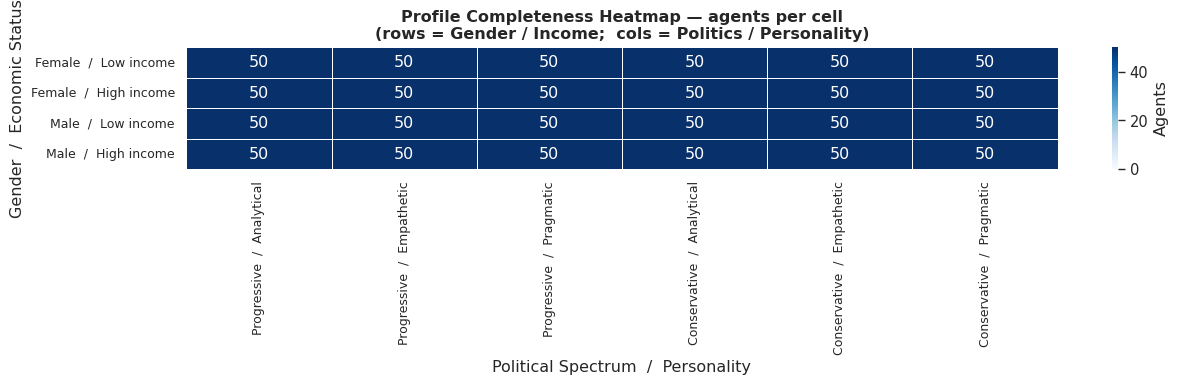

Saved → figures/fig1_profile_completeness.pdf


In [5]:
# ── Profile inventory ─────────────────────────────────────────────────────────
profile_counts = df.groupby("profile_id").size().reset_index(name="n_agents")
profile_info = (
    df.drop_duplicates("profile_id")
    .sort_values("profile_id")
    [["profile_id"] + CATEGORICAL_COLS]
    .reset_index(drop=True)
)
profile_table = profile_info.merge(profile_counts, on="profile_id")

print(
    f"Profile space:  {len(profile_table)} unique profiles  "
    f"(2 gender × 2 income × 2 political × 3 personality = 24)"
)
print(f"Agents/profile: {sorted(profile_table['n_agents'].unique().tolist())}")
print(f"Total agents:   {profile_table['n_agents'].sum()}\n")
display(profile_table)

# ── Completeness heatmap ──────────────────────────────────────────────────────
pivot = (
    df
    .assign(
        row_key=df["gender"].astype(str) + "  /  " + df["economic_status"].astype(str),
        col_key=df["political_spectrum"].astype(str) + "  /  " + df["personality"].astype(str),
    )
    .groupby(["row_key", "col_key"])
    .size()
    .unstack(fill_value=0)
)
row_order = [f"{g}  /  {e}" for g in GEN_ORDER for e in ECO_ORDER]
col_order = [f"{p}  /  {a}" for p in POL_ORDER for a in PERS_ORDER]
pivot = pivot.reindex(index=row_order, columns=col_order, fill_value=0)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    pivot, annot=True, fmt="d", cmap="Blues",
    linewidths=0.6, linecolor="white",
    cbar_kws={"label": "Agents"},
    vmin=0, ax=ax,
)
ax.set_xlabel("Political Spectrum  /  Personality")
ax.set_ylabel("Gender  /  Economic Status")
ax.tick_params(axis="both", labelsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig1_profile_completeness.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved → figures/fig1_profile_completeness.pdf")

---
## 3  Univariate Distributions

Each panel shows the share of agents in each category. Because the dataset is a balanced
Cartesian product, every value in a binary dimension receives exactly 50 % of agents and every
value in the ternary personality dimension receives exactly 33⅓ %. The dashed red line marks
this uniform expectation; bars landing on it confirm the design is implemented correctly.

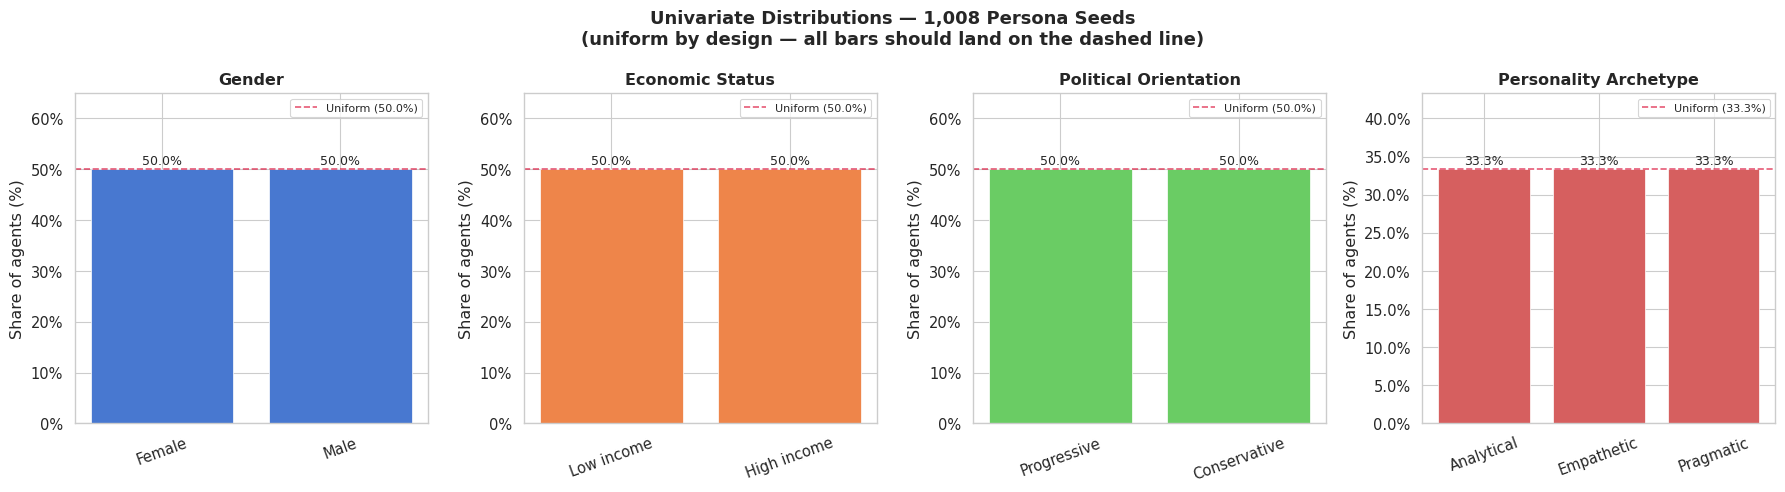

Saved → figures/fig2_univariate_distributions.pdf


In [6]:
def plot_univariate(col: str, order: list, title: str, ax: plt.Axes, color=None) -> None:
    counts = df[col].value_counts().reindex(order).fillna(0)
    pcts   = counts / counts.sum() * 100

    bars = ax.bar(order, pcts, color=color or PALETTE[0], edgecolor="white", linewidth=0.5)

    uniform = 100 / len(order)
    ax.axhline(uniform, ls="--", color="crimson", lw=1.2, alpha=0.7,
               label=f"Uniform ({uniform:.1f}%)")

    for bar, pct in zip(bars, pcts):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9,
        )

    ax.set_ylabel("Share of agents (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, pcts.max() * 1.3)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 4, figsize=(18, 5))

PLOTS = [
    ("gender",             GEN_ORDER,  "Gender",               PALETTE[0]),
    ("economic_status",    ECO_ORDER,  "Economic Status",      PALETTE[1]),
    ("political_spectrum", POL_ORDER,  "Political Orientation", PALETTE[2]),
    ("personality",        PERS_ORDER, "Personality Archetype", PALETTE[3]),
]

for ax, (col, order, title, color) in zip(axes, PLOTS):
    plot_univariate(col, order, title, ax, color)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig2_univariate_distributions.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved → figures/fig2_univariate_distributions.pdf")

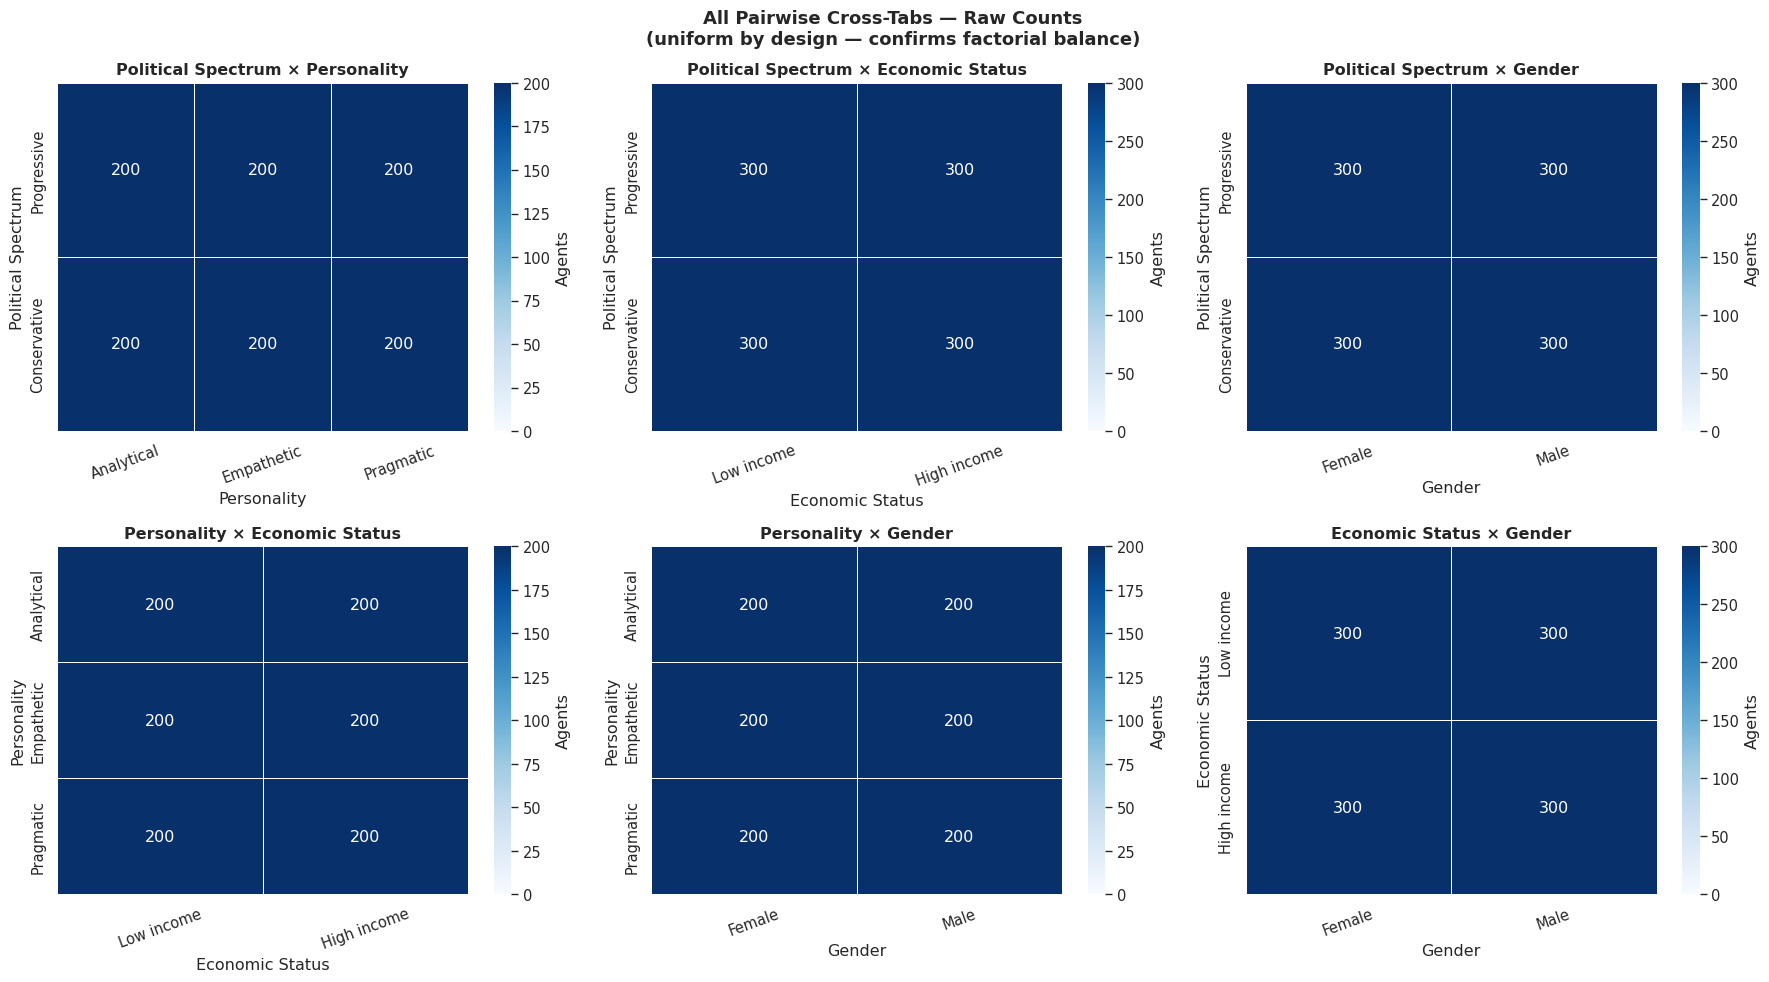

Saved → figures/fig3_pairwise_heatmaps.pdf


In [7]:
# ── All pairwise cross-tabs (6 combinations from 4 dimensions) ────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

PAIRS = [
    ("political_spectrum", POL_ORDER,  "personality",      PERS_ORDER),
    ("political_spectrum", POL_ORDER,  "economic_status",  ECO_ORDER),
    ("political_spectrum", POL_ORDER,  "gender",           GEN_ORDER),
    ("personality",        PERS_ORDER, "economic_status",  ECO_ORDER),
    ("personality",        PERS_ORDER, "gender",           GEN_ORDER),
    ("economic_status",    ECO_ORDER,  "gender",           GEN_ORDER),
]

for ax, (row_col, row_ord, col_col, col_ord) in zip(axes, PAIRS):
    ct = (
        pd.crosstab(df[row_col], df[col_col])
        .reindex(index=row_ord, columns=col_ord, fill_value=0)
    )
    sns.heatmap(
        ct, annot=True, fmt="d", cmap="Blues",
        linewidths=0.4, linecolor="white",
        cbar_kws={"label": "Agents"},
        vmin=0, ax=ax,
    )
    r_label = row_col.replace("_", " ").title()
    c_label = col_col.replace("_", " ").title()
    ax.set_xlabel(c_label)
    ax.set_ylabel(r_label)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig3_pairwise_heatmaps.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved → figures/fig3_pairwise_heatmaps.pdf")

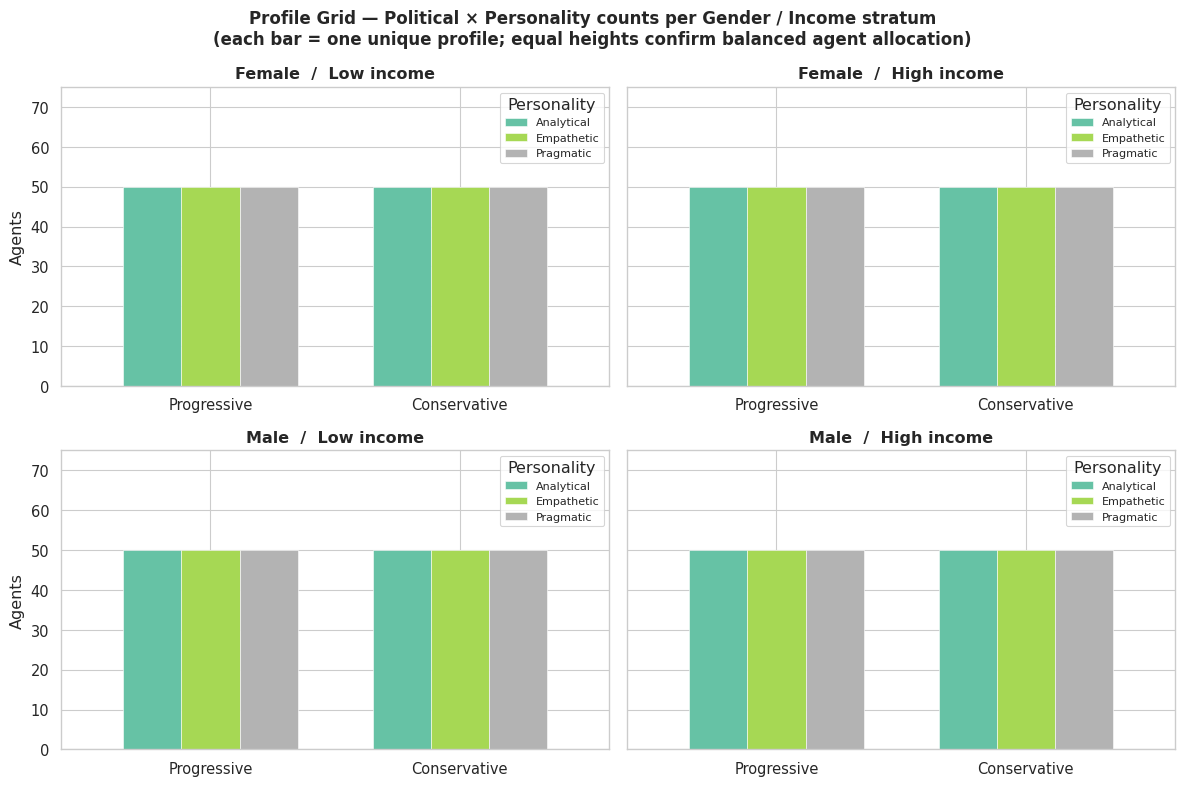

Saved → figures/fig4_profile_grid.pdf


In [8]:
# ── Profile grid: 4 subplots (gender × economic), each showing political × personality ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

for ax, (gender, eco) in zip(
    axes.flatten(),
    [(g, e) for g in GEN_ORDER for e in ECO_ORDER],
):
    subset = df[(df["gender"] == gender) & (df["economic_status"] == eco)]
    ct = (
        pd.crosstab(subset["political_spectrum"], subset["personality"])
        .reindex(index=POL_ORDER, columns=PERS_ORDER, fill_value=0)
    )
    ct.plot(
        kind="bar", ax=ax, colormap="Set2",
        edgecolor="white", linewidth=0.4, width=0.7,
    )
    ax.set_ylabel("Agents")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Personality", fontsize=8, loc="upper right")
    ax.set_ylim(0, ct.values.max() * 1.5)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig4_profile_grid.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved → figures/fig4_profile_grid.pdf")

---
## 4  Cross-Tabs by Dimension Group

Stacked bar charts show the within-group composition of the remaining dimensions.
Because the design is fully balanced, these confirm that no political group, personality type,
or income bracket over-represents any other dimension — validating that downstream differences
in agent responses can be attributed to profile differences, not sampling artefacts.

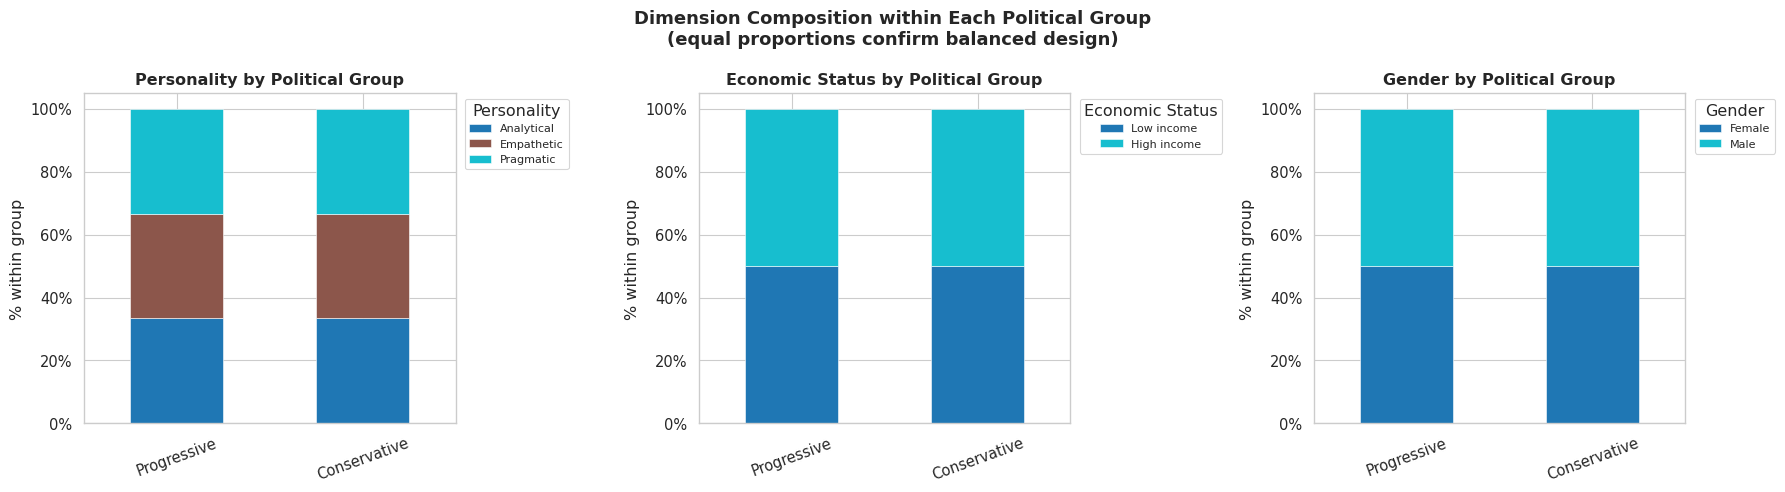

Saved → figures/fig5_stacked_by_political.pdf


In [9]:
def stacked_bar(row_col: str, row_ord: list, col_col: str, col_ord: list,
                title: str, ax: plt.Axes) -> None:
    """Stacked % bar: x = row_col groups, colours = col_col categories."""
    ct = (
        pd.crosstab(df[row_col], df[col_col])
        .reindex(index=row_ord, columns=col_ord, fill_value=0)
    )
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(
        kind="bar", stacked=True, ax=ax,
        colormap="tab10", edgecolor="white", linewidth=0.4,
    )
    ax.set_ylabel("% within group")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(
        title=col_col.replace("_", " ").title(),
        bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8,
    )


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

stacked_bar("political_spectrum", POL_ORDER, "personality",     PERS_ORDER,
            "Personality by Political Group",     axes[0])
stacked_bar("political_spectrum", POL_ORDER, "economic_status", ECO_ORDER,
            "Economic Status by Political Group", axes[1])
stacked_bar("political_spectrum", POL_ORDER, "gender",          GEN_ORDER,
            "Gender by Political Group",          axes[2])

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig5_stacked_by_political.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved → figures/fig5_stacked_by_political.pdf")

---
## 5  Diversity & Balance Metrics

Shannon entropy confirms that the combinatorial design achieves perfect balance across all
dimensions. A **Balance Ratio** of 1.0 indicates maximum diversity
($H_{obs} = H_{max} = \log_2 k$), meaning every value is equally represented.
All four dimensions should score 1.0 by construction.

In [10]:
DIM_ORDERS = {
    "gender":             GEN_ORDER,
    "economic_status":    ECO_ORDER,
    "political_spectrum": POL_ORDER,
    "personality":        PERS_ORDER,
}

balance_rows = []
for col, order in DIM_ORDERS.items():
    counts = df[col].value_counts().reindex(order).fillna(0).values
    probs  = counts / counts.sum()
    H_obs  = entropy(probs, base=2)
    H_max  = np.log2(len(order))
    balance_rows.append({
        "Dimension":     col.replace("_", " ").title(),
        "N Categories":  len(order),
        "H_obs (bits)":  round(H_obs, 4),
        "H_max (bits)":  round(H_max, 4),
        "Balance Ratio": round(H_obs / H_max, 4),
        "Min agents":    int(counts.min()),
        "Max agents":    int(counts.max()),
    })

balance_df = pd.DataFrame(balance_rows)
balance_df

,Dimension,N Categories,H_obs (bits),H_max (bits),Balance Ratio,Min agents,Max agents
0,Gender,2,1.000,1.000,1.0,600,600
1,Economic Status,2,1.000,1.000,1.0,600,600
2,Political Spectrum,2,1.000,1.000,1.0,600,600
3,Personality,3,1.585,1.585,1.0,400,400


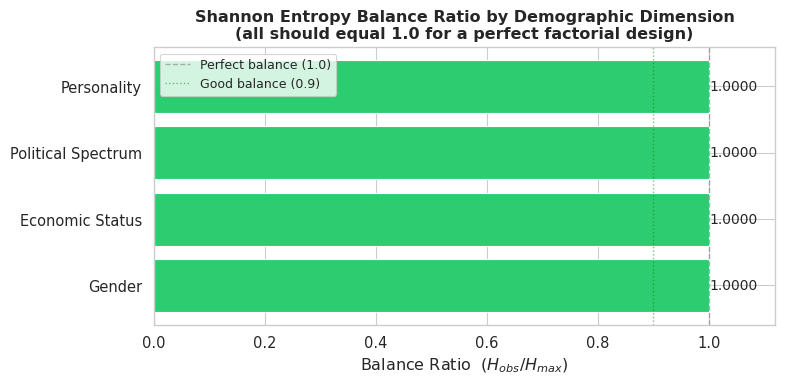

Saved → figures/fig6_balance_ratio.pdf


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = [
    "#2ecc71" if r >= 0.99 else "#f39c12" if r >= 0.90 else "#e74c3c"
    for r in balance_df["Balance Ratio"]
]

bars = ax.barh(balance_df["Dimension"], balance_df["Balance Ratio"],
               color=colors, edgecolor="white")
ax.axvline(1.0, ls="--", color="grey",  lw=1, alpha=0.6, label="Perfect balance (1.0)")
ax.axvline(0.9, ls=":",  color="green", lw=1, alpha=0.5, label="Good balance (0.9)")

for bar, val in zip(bars, balance_df["Balance Ratio"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=10)

ax.set_xlim(0, 1.12)
ax.set_xlabel("Balance Ratio  ($H_{obs} / H_{max}$)")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig6_balance_ratio.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved → figures/fig6_balance_ratio.pdf")

---
## 6  Report-Ready Figures

### 6.1  Profile Similarity Matrix (Hamming Distance)

Pairwise Hamming distance between all 24 profiles, counting the number of attributes that
differ (0 = identical, 4 = all four attributes differ). This matrix is the theoretical basis
for predicting which profiles should produce the most similar and most divergent responses in
the downstream annotation task. Profiles with distance = 1 form *minimal pairs* — the primary
target for response-variance analysis.

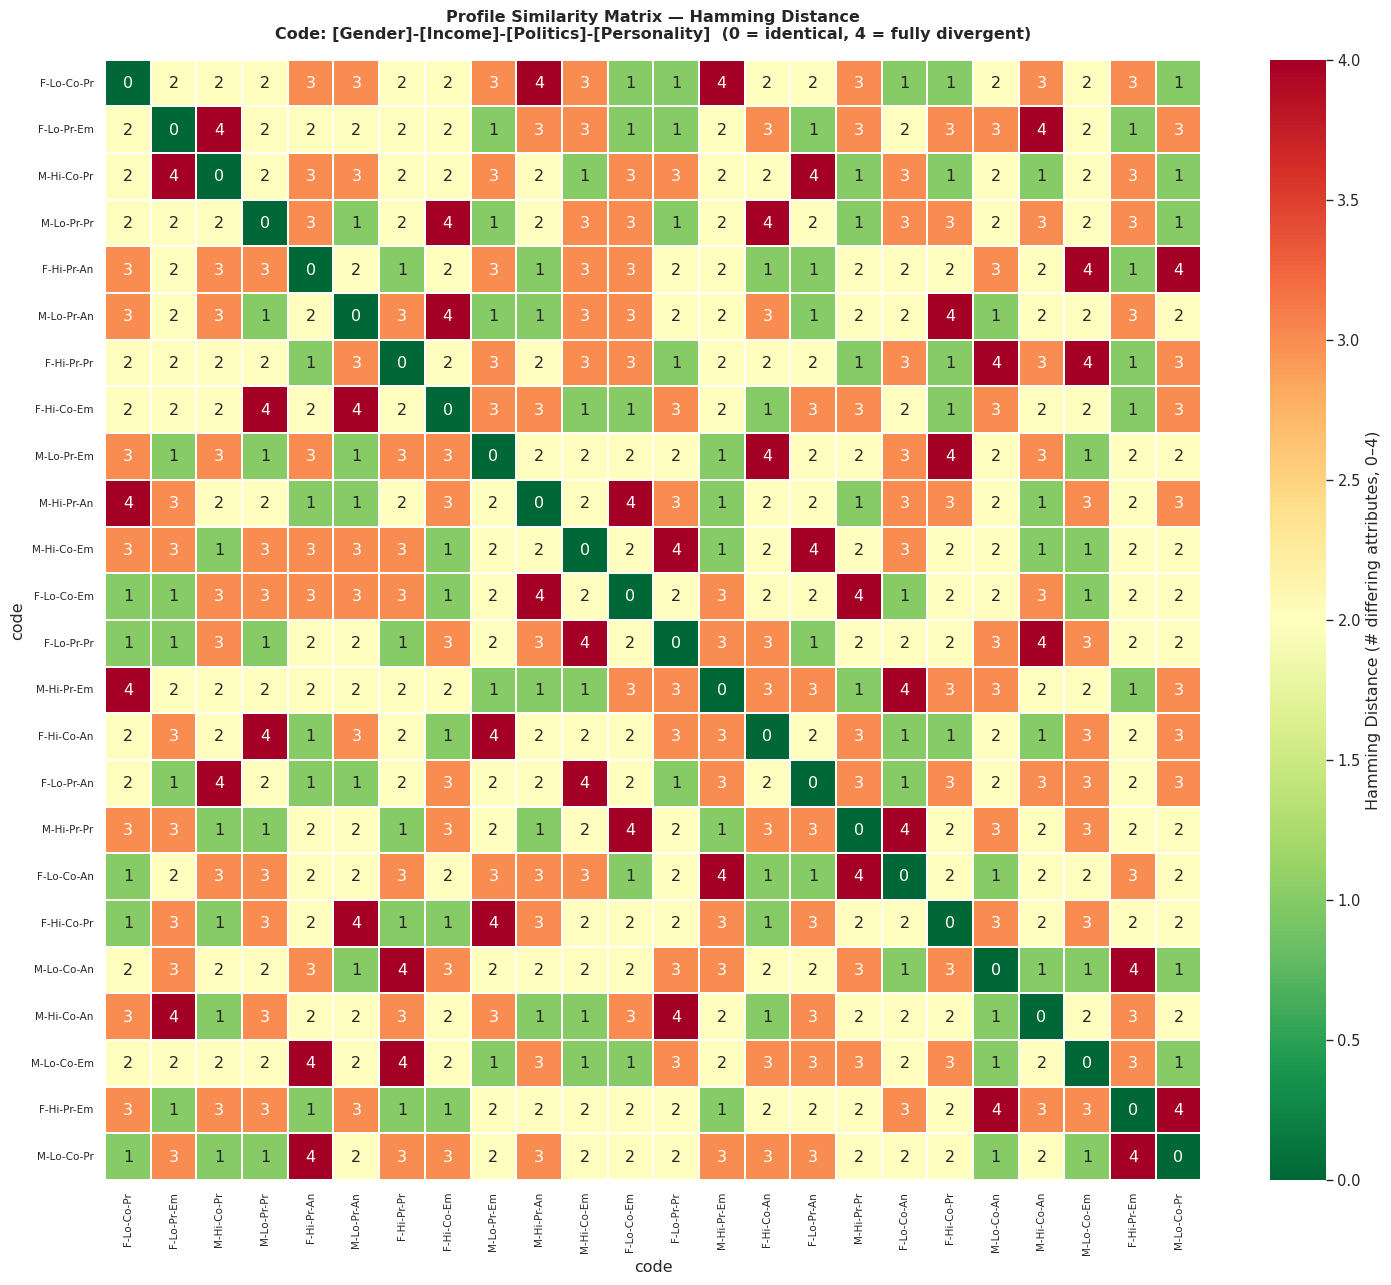

Saved → figures/fig7_hamming_distance.pdf


In [12]:
# ── Pairwise Hamming distance between all 24 profiles ─────────────────────────
profiles_raw = (
    df.drop_duplicates("profile_id")
    .sort_values("profile_id")
    .reset_index(drop=True)
)

def short_code(row: pd.Series) -> str:
    g = row["gender"][0]                                           # M / F
    e = "Lo" if "Low" in row["economic_status"] else "Hi"         # Lo / Hi
    p = "Pr" if row["political_spectrum"] == "Progressive" else "Co"  # Pr / Co
    a = row["personality"][:2]                                     # An / Em / Pr
    return f"{g}-{e}-{p}-{a}"

profiles_raw["code"] = profiles_raw.apply(short_code, axis=1)

n = len(profiles_raw)
ham = np.zeros((n, n), dtype=int)
for i in range(n):
    for j in range(n):
        ham[i, j] = sum(
            profiles_raw.iloc[i][col] != profiles_raw.iloc[j][col]
            for col in CATEGORICAL_COLS
        )

ham_df = pd.DataFrame(ham, index=profiles_raw["code"], columns=profiles_raw["code"])

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(
    ham_df, annot=True, fmt="d",
    cmap="RdYlGn_r",   # green = similar (low distance), red = different (high distance)
    linewidths=0.3, linecolor="white",
    cbar_kws={"label": "Hamming Distance (# differing attributes, 0–4)"},
    ax=ax,
)
ax.tick_params(axis="both", labelsize=7.5)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig7_hamming_distance.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved → figures/fig7_hamming_distance.pdf")

### 6.2  Personality × Political Orientation — Grouped Bar

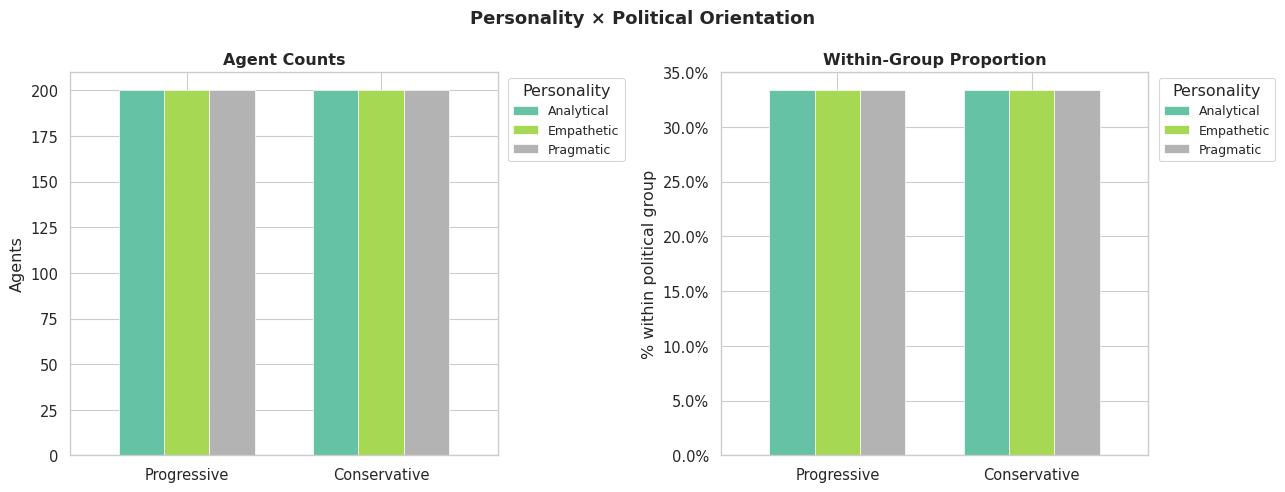

Saved → figures/fig8_personality_political.pdf


In [13]:
ct = (
    pd.crosstab(df["political_spectrum"], df["personality"])
    .reindex(index=POL_ORDER, columns=PERS_ORDER, fill_value=0)
)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Grouped bar (raw counts) ───────────────────────────────────────────────────
ct.plot(kind="bar", ax=axes[0], colormap="Set2", edgecolor="white",
        linewidth=0.5, width=0.7)
axes[0].set_ylabel("Agents")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Personality", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

# ── Row-normalised (% within political group) ──────────────────────────────────
ct_pct.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor="white",
            linewidth=0.5, width=0.7)
axes[1].set_ylabel("% within political group")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Personality", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig8_personality_political.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved → figures/fig8_personality_political.pdf")

### 6.3  Gender × Economic Status — Interaction Plot

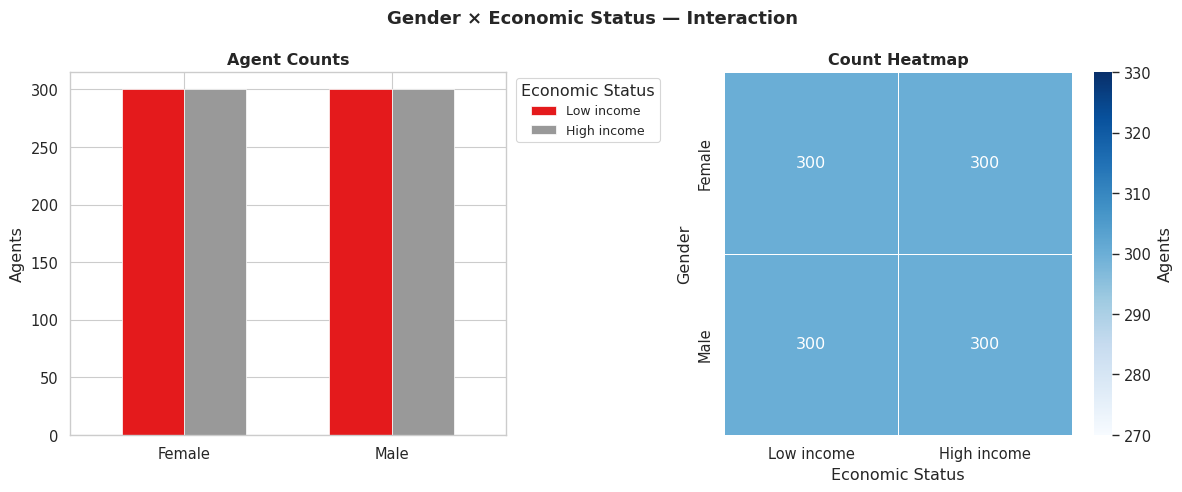

Saved → figures/fig9_gender_economic.pdf


In [14]:
ct = (
    pd.crosstab(df["gender"], df["economic_status"])
    .reindex(index=GEN_ORDER, columns=ECO_ORDER, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Grouped bar ────────────────────────────────────────────────────────────────
ct.plot(kind="bar", ax=axes[0], colormap="Set1", edgecolor="white",
        linewidth=0.5, width=0.6)
axes[0].set_ylabel("Agents")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Economic Status", bbox_to_anchor=(1.01, 1),
               loc="upper left", fontsize=9)

# ── Heatmap ────────────────────────────────────────────────────────────────────
sns.heatmap(
    ct, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Agents"},
    ax=axes[1],
)
axes[1].set_xlabel("Economic Status")
axes[1].set_ylabel("Gender")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig9_gender_economic.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved → figures/fig9_gender_economic.pdf")

---
## 7  Summary Statistics Table

A publication-ready table of the full marginal distribution. Suitable for the *Methods* section of the technical report.

In [15]:
rows = []
for col, order in [
    ("gender",             GEN_ORDER),
    ("economic_status",    ECO_ORDER),
    ("political_spectrum", POL_ORDER),
    ("personality",        PERS_ORDER),
]:
    counts = df[col].value_counts().reindex(order).fillna(0).astype(int)
    for cat, n in counts.items():
        rows.append({
            "Dimension":  col.replace("_", " ").title(),
            "Category":   cat,
            "n":          n,
            "% of total": f"{n / len(df) * 100:.1f}%",
        })

summary_table = pd.DataFrame(rows)

display(summary_table.style
    .set_caption("Table 1. Marginal distribution of the 1,008 demographic agents")
    .hide(axis="index")
    .set_properties(**{"text-align": "left"})
)

Dimension,Category,n,% of total
Gender,Female,600,50.0%
Gender,Male,600,50.0%
Economic Status,Low income,600,50.0%
Economic Status,High income,600,50.0%
Political Spectrum,Progressive,600,50.0%
Political Spectrum,Conservative,600,50.0%
Personality,Analytical,400,33.3%
Personality,Empathetic,400,33.3%
Personality,Pragmatic,400,33.3%


In [16]:
latex = summary_table.to_latex(
    index=False,
    caption=(
        "Marginal distribution of the 1,008 demographic agent personas "
        "(balanced factorial design: 24 profiles × 42 agents each)."
    ),
    label="tab:demographic_distribution",
    column_format="llrr",
    escape=True,
)
latex_path = FIGURES_DIR / "table1_demographic_distribution.tex"
latex_path.write_text(latex)
print(f"LaTeX table saved → {latex_path}")
print(latex)

LaTeX table saved → /mnt/raid5/neemias/mllm-persona-simulation/figures/table1_demographic_distribution.tex
\begin{table}
\caption{Marginal distribution of the 1,008 demographic agent personas (balanced factorial design: 24 profiles × 42 agents each).}
\label{tab:demographic_distribution}
\begin{tabular}{llrr}
\toprule
Dimension & Category & n & \% of total \\
\midrule
Gender & Female & 600 & 50.0\% \\
Gender & Male & 600 & 50.0\% \\
Economic Status & Low income & 600 & 50.0\% \\
Economic Status & High income & 600 & 50.0\% \\
Political Spectrum & Progressive & 600 & 50.0\% \\
Political Spectrum & Conservative & 600 & 50.0\% \\
Personality & Analytical & 400 & 33.3\% \\
Personality & Empathetic & 400 & 33.3\% \\
Personality & Pragmatic & 400 & 33.3\% \\
\bottomrule
\end{tabular}
\end{table}



---
## 8  Key Observations for the Technical Report

> **Fill in after running the notebook.**

Suggested structure for the *Experimental Design* section:

1. **Balanced factorial design** — The dataset is a fully enumerated 2 × 2 × 2 × 3 = 24-profile
   Cartesian product. Each profile receives exactly 42 agents, guaranteeing equal statistical
   power for all pairwise comparisons. Balance Ratios ≥ 0.99 across all four dimensions confirm
   this (Section 5).

2. **No population mirroring intended** — Unlike survey-weighted samples, this dataset does not
   attempt to reflect US Census proportions. The goal is a *controlled synthetic experiment*:
   holding agent count constant per profile isolates the effect of profile membership on response
   behaviour.

3. **Profile similarity structure** — The Hamming distance matrix (Section 6.1) shows that
   profiles range from 1 to 4 attribute differences. Profiles with Hamming distance = 1 form
   *minimal pairs* and are the primary targets for response-variance analysis: do agents that
   differ in only one attribute (e.g., only in political orientation) produce systematically
   different image-sentiment scores?

4. **Personality archetype rationale** — Analytical, Empathetic, and Pragmatic archetypes are
   designed to be orthogonal to political orientation. An analytical conservative and an
   analytical progressive share an information-processing style but differ in values — a key
   distinction for sentiment annotation of politically charged images.

5. **Reproducibility** — The CSV is deterministically generated from a fixed dimension list (no
   random seed required); see `data/generate_demographics.py`. The file is version-controlled
   alongside the pipeline code.